# ONE FC Streaming Platform — Data Analysis
**Author:** Warinthip Arakkul | **Dataset Period:** Jan–May 2026

---

## 1. Setup & Data Loading

In [9]:
import pandas as pd
import numpy as np

#set path
path = r"C:\Users\ASUS\Downloads\Data" + "\\"

#load data
users     = pd.read_csv(path + 'userdata.csv')
views     = pd.read_csv(path + 'viewdata.csv')
purchases = pd.read_csv(path + 'purchase_data.csv')

#check data size
print("userdata     :", users.shape)
print("viewdata     :", views.shape)
print("purchase_data:", purchases.shape)

userdata     : (65032, 8)
viewdata     : (1048575, 8)
purchase_data: (89434, 19)


---

## 2. Exploratory Data Analysis (EDA)

Preview each dataset to understand structure, column names, and data types.

In [14]:
users.head() #check data header_users

,id,user_id,country,signup_date,date_joined,last_login,is_active,is_staff
0,13,6,NL,36:53.9,36:53.0,31:17.0,1,1
1,75,17,US,04:58.8,04:58.0,02:27.7,1,1
2,120,23,USA,51:05.6,51:05.0,03:49.6,1,1
3,146,31,US,53:09.0,53:06.8,NaN,1,0
4,152,32,TH,04:29.5,04:29.1,14:16.5,1,0


In [15]:
views.head() #check data header_view

,id,join_time,leave_time,leave_type,kiswe_user_id,user_session_count,geo_country,event
0,2830548,54:17.6,54:18.5,leave,17,1,NaN,No Event
1,2830576,35:28.6,35:32.3,leave,17,1,GB,No Event
2,2830585,19:56.6,20:02.0,leave,207290,1,TH,No Event
3,2830602,03:49.7,04:27.2,leave,189011,1,TH,No Event
4,2830606,06:35.0,07:23.3,leave,202203,1,TH,No Event


In [16]:
purchases.head() #check data header_purchase

,order_id,internal_name,paid_event_name,charges_in_usd,time_created,time_ordered,time_cancelled,time_refund_processed,dispute_status,time_last_dispute_update,unit_price,fees,tax,total_charges,currency,total_charges_usd,user_id,status,payment_vendor
0,8cd5d32f-0ee0-4aa9-a1d0-b49039dbf117,Ticket_OneFC_3MonthPass,ONE_PASS,"{\n ""city_taxes"": ""0.54"",\n ""county_taxes"": ...",2026-01-29 03:44:00.8580360,2026/01/29,NaN,2024-01-01 00:00:00,NaN,NaN,12.99,0.78,1.56,15.33,USD,15.33,17.0,completed,stripe
1,9546f6a4-0f7e-4144-9b6c-164c1fcb2df7,Ticket_ONEFC_MonthlyPass,ONE_PASS,"{\n ""city_taxes"": ""0.00"",\n ""county_taxes"": ...",2026-01-29 17:27:03.4240400,2026-01-29 17:26:44.9763380,2026-01-29 20:46:32.5659050,2026-01-29 20:46:32.5659050,NaN,NaN,6.50,0.39,0.00,6.89,USD,6.89,303425.0,canceled,Stripe
2,7f261b7d-a77b-477a-8fe0-d99de7ed40ef,Ticket_ONEFC_MonthlyPass,ONE_PASS,"{\n ""city_taxes"": ""0.00"",\n ""county_taxes"": ...",2026-01-30 06:03:59.8843200,2026-01-30 06:03:19.0000000,2026-02-02 08:28:20.0000000,2026-02-02 08:28:20.0000000,NaN,NaN,199.00,11.94,14.77,225.71,USD,7.19,303433.0,canceled,Xendit
3,8fe7a6bd-3d00-4970-ab97-2b88fedfc8a2,Ticket_ONEFC_MonthlyPass,ONE_PASS,"{\n ""city_taxes"": ""0.00"",\n ""county_taxes"": ...",2026-01-30 06:08:07.5378850,2026-01-30 06:07:37.0000000,2026-02-02 08:29:34.0000000,02-02-2026,NaN,NaN,199.00,11.94,14.77,225.71,USD,7.19,186951.0,canceled,Xendit
4,ffddf7c1-2c80-40b7-8864-3ea7fda2adfa,Ticket_ONEFC_MonthlyPass,ONE_PASS,"{\n ""city_taxes"": ""0.00"",\n ""county_taxes"": ...",2026-01-30 06:27:46.4411630,2026-01-30 06:27:32.0000000,2026-02-02 06:43:31.0000000,2026-02-02 06:43:31.0000000,NaN,NaN,199.00,11.94,14.77,225.71,USD,7.19,192808.0,canceled,stripe


In [17]:
#find missing value
print("=== MISSING VALUES ===")
print("\n-- users --")
print(users.isnull().sum())

print("\n-- views --")
print(views.isnull().sum())

print("\n-- purchases --")
print(purchases.isnull().sum())

=== MISSING VALUES ===

-- users --
id                 0
user_id            0
country         5185
signup_date        0
date_joined        0
last_login     52294
is_active          0
is_staff           0
dtype: int64

-- views --
id                         0
join_time                  0
leave_time             81474
leave_type            115759
kiswe_user_id              0
user_session_count         0
geo_country            83902
event                      0
dtype: int64

-- purchases --
order_id                        0
internal_name                   0
paid_event_name                 0
charges_in_usd                  3
time_created                    0
time_ordered                    0
time_cancelled              89330
time_refund_processed       85739
dispute_status              89430
time_last_dispute_update    89430
unit_price                      0
fees                            0
tax                             0
total_charges                   0
currency                        

---

## 3. Data Cleaning

Normalize inconsistent values across all three datasets before analysis.

**Issues addressed:**
- Country codes: mixed formats (TH / THA / Thailand) → ISO 3166-1 alpha-2
- `is_active` / `is_staff`: mixed boolean types (0/1, Y/N) → integer 0/1
- Order status: mixed casing (Fulfilled / FULFILLED) → lowercase
- Payment vendor: mixed casing (Stripe / STRIPE) → title case
- Currency: leading/trailing spaces → stripped and uppercased
- Duplicate user_id rows removed (1,894 found in raw data)

In [22]:
#Too many inconsistent data, need to clean first

#Clean User file
#First normalize countries
#Merge several abbri into 1 country 
country_map = {
    'thai': 'TH', 'Thailand': 'TH', 'THA': 'TH',
    'USA' : 'US', 'united states': 'US',
    'UK'  : 'GB', 'United Kingdom': 'GB',
}
users['country'] = (users['country']
                    .replace(country_map)
                    .str.upper()
                    .str.strip())

#normalize is_active, is_staff
bool_map = {'1':1,'y':1,'yes':1,'0':0,'n':0,'no':0}
users['is_active'] = users['is_active'].astype(str).str.lower().map(bool_map)
users['is_staff']  = users['is_staff'].astype(str).str.lower().map(bool_map)

#Cut duplicate user_id out (keep only first line)
before = len(users)
users = users.drop_duplicates(subset='user_id', keep='first')
print(f"Delete Duplicate Users: {before - len(users)} rows")
print(f"Remain Users: {len(users):,}")
#Clean User file end here

#Clean Purchase file
#normalize status
status_map = {
    'fulfilled':'fulfilled','Fulfilled':'fulfilled','FULFILLED':'fulfilled',
    'completed':'completed','COMPLETED':'completed',
    'success'  :'completed','paid':'completed',
    'refunded' :'refunded',
    'cancelled':'cancelled','canceled':'cancelled','cancel_pending':'cancelled',
    'order_disputed':'disputed',
}
purchases['status'] = purchases['status'].str.strip().map(status_map)

#normalize payment_vendor
purchases['payment_vendor'] = purchases['payment_vendor'].str.strip().str.title()

#normalize currency
purchases['currency'] = purchases['currency'].str.strip().str.upper()
#Clean Purchase file end here

#Clean View file
#normalize geo_country
views['geo_country'] = (views['geo_country']
                        .replace(country_map)
                        .str.upper()
                        .str.strip())

print("\nData Cleaning Done ✅")
print("\nStatus after Clean:")
print(purchases['status'].value_counts())

Delete Duplicate Users: 0 rows
Remain Users: 63,138

Data Cleaning Done ✅

Status after Clean:
status
fulfilled    73860
completed    13754
cancelled      962
refunded       854
Name: count, dtype: int64


---

## 4. Revenue Analysis

Using `total_charges_usd` as the revenue metric (already converted to USD by the platform).  
Only orders with status `fulfilled` or `completed` are included.

> **Note:** `tax` and `unit_price` columns are in local currency — not used in revenue calculations.

In [39]:
#select only orders that payment is successful 
#But what is the difference between fulfilled and completed...let's assume they are both successful orders
paid = purchases[purchases['status'].isin(['fulfilled', 'completed'])].copy()

#parse date
paid['time_ordered'] = pd.to_datetime(paid['time_ordered'], errors='coerce')
paid['order_date']   = paid['time_ordered'].dt.date
paid['order_month']  = paid['time_ordered'].dt.to_period('M')

print("=== REVENUE OVERVIEW ===")
print(f"Total Revenue  : ${paid['total_charges_usd'].sum():>12,.2f}")
print(f"Total Orders   : {len(paid):>12,}")
print(f"Avg Order Value: ${paid['total_charges_usd'].mean():>12.2f}")
print(f"Cancel Rate    : {len(purchases[purchases['status']=='cancelled'])/len(purchases)*100:.1f}%")

print("\n--- Revenue by Product ---")
print(paid.groupby('internal_name')['total_charges_usd']
      .agg(['sum','count','mean'])
      .sort_values('sum', ascending=False)
      .round(2))

=== REVENUE OVERVIEW ===
Total Revenue  : $  678,258.92
Total Orders   :       87,614
Avg Order Value: $        7.74
Cancel Rate    : 1.1%

--- Revenue by Product ---
                                sum  count   mean
internal_name                                    
Ticket_ONEFC_MonthlyPass  429274.36  62902   6.82
Subscription_One_Monthly  158394.73  18467   8.58
Ticket_OneFC_3MonthPass    90589.83   6242  14.51


In [40]:
#check tax
print(paid[['total_charges_usd', 'tax', 'unit_price', 'fees']].head(10))
print(f"\ntax stats:\n{paid['tax'].describe()}")
print(f"\nfees stats:\n{paid['fees'].describe()}")

    total_charges_usd    tax  unit_price  fees
0               15.33   1.56       12.99  0.78
19              13.23  27.30      390.00  0.00
20              13.23  27.30      390.00  0.00
21               5.42  11.20      160.00  0.00
22              13.24  27.30      390.00  0.00
23               5.42  11.20      160.00  0.00
24              13.24  27.30      390.00  0.00
25              13.24  27.30      390.00  0.00
26              13.24  27.30      390.00  0.00
27               5.42  11.20      160.00  0.00

tax stats:
count    87614.000000
mean        16.525139
std         71.065955
min          0.000000
25%         11.200000
50%         14.000000
75%         14.000000
max       8400.000000
Name: tax, dtype: float64

fees stats:
count    87614.000000
mean         0.000009
std          0.002635
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.780000
Name: fees, dtype: float64


In [41]:
#unit price is a problem...some is in THB; cant use unit_price (need conversion)
print(paid[['total_charges_usd', 'tax', 'unit_price', 
            'fees', 'currency']].head(20))

    total_charges_usd    tax  unit_price  fees currency
0               15.33   1.56       12.99  0.78      USD
19              13.23  27.30      390.00  0.00      THB
20              13.23  27.30      390.00  0.00      THB
21               5.42  11.20      160.00  0.00      THB
22              13.24  27.30      390.00  0.00      THB
23               5.42  11.20      160.00  0.00      THB
24              13.24  27.30      390.00  0.00      THB
25              13.24  27.30      390.00  0.00      THB
26              13.24  27.30      390.00  0.00      THB
27               5.42  11.20      160.00  0.00      THB
28              13.21  27.30      390.00  0.00      THB
29              13.21  27.30      390.00  0.00      THB
30              13.21  27.30      390.00  0.00      THB
31              13.21  27.30      390.00  0.00      THB
32              13.21  27.30      390.00  0.00      THB
33              13.21  27.30      390.00  0.00      THB
34               5.42  11.20      160.00  0.00  

In [42]:
#Revenue calculation check 
total_rev = paid['total_charges_usd'].sum()
thb_rev = paid[paid['currency']=='THB']['total_charges_usd'].sum()
print(f"THB revenue: ${thb_rev:,.2f}")
print(f"Total revenue: ${total_rev:,.2f}")
print(f"THB share: {thb_rev/total_rev*100:.1f}%")

THB revenue: $571,964.08
Total revenue: $678,258.92
THB share: 84.3%


In [35]:
#Daily revenue
print("--- Daily Revenue ---")
daily = (paid.groupby('order_date')['total_charges_usd']
         .sum()
         .sort_index())
print(daily.to_string())

--- Daily Revenue ---
order_date
2026-01-29      15.33
2026-02-04      21.63
2026-02-05      42.47
2026-02-06     527.52
2026-02-08       5.44
2026-02-11      35.44
2026-02-12      32.45
2026-02-13     308.69
2026-02-16      18.93
2026-02-19       5.50
2026-02-20     149.96
2026-02-21       5.51
2026-02-26      16.53
2026-02-27     424.62
2026-03-01       5.51
2026-03-02      16.41
2026-03-04      10.84
2026-03-05      13.18
2026-03-06      77.52
2026-03-08       5.38
2026-03-09       5.33
2026-03-10       5.39
2026-03-11       5.40
2026-03-12      16.06
2026-03-13     233.78
2026-03-14      49.82
2026-03-15     123.74
2026-03-16     201.68
2026-03-17     104.08
2026-03-18     328.45
2026-03-19     901.82
2026-03-20    5234.96
2026-03-21      43.03
2026-03-22       6.51
2026-03-26      13.06
2026-03-27     115.42
2026-03-28      12.42
2026-03-30      15.63
2026-03-31      15.65
2026-04-01      15.70
2026-04-02      28.82
2026-04-03     106.85
2026-04-08      12.27
2026-04-09      12.08

In [36]:
#Monthly revenue and peak day each month
print("--- Monthly Revenue ---")
monthly = (paid.groupby('order_month')['total_charges_usd']
           .agg(['sum', 'count', 'max'])
           .rename(columns={'sum':'revenue','count':'orders','max':'peak_day'}))
print(monthly.round(2))

print("\n--- Peak Day per Month ---")
for month, group in paid.groupby('order_month'):
    peak = group.groupby('order_date')['total_charges_usd'].sum().idxmax()
    peak_val = group.groupby('order_date')['total_charges_usd'].sum().max()
    print(f"{month}: {peak} = ${peak_val:,.2f}")

--- Monthly Revenue ---
             revenue  orders  peak_day
order_month                           
2026-01        15.33       1     15.33
2026-02      1594.69     232     13.47
2026-03      7561.07    1050     15.91
2026-04      1141.47     135     16.01
2026-05      5334.05     630     15.80

--- Peak Day per Month ---
2026-01: 2026-01-29 = $15.33
2026-02: 2026-02-06 = $527.52
2026-03: 2026-03-20 = $5,234.96
2026-04: 2026-04-24 = $316.37
2026-05: 2026-05-15 = $2,982.86


In [38]:
#Revenue by Payment Vendor
print("\n--- Revenue by Payment Vendor ---")
print(paid.groupby('payment_vendor')['total_charges_usd']
      .agg(['sum','count'])
      .sort_values('sum', ascending=False)
      .round(2))


--- Revenue by Payment Vendor ---
                      sum  count
payment_vendor                  
Omise           341084.48  44819
Xendit          146560.82  20821
Stripe          131807.74  13623
Antom            53196.31   7809
Paypal            5609.57    520
Comped               0.00     19


---

## 5. Geographic Analysis

Comparing where users registered (`country`) vs where they actually watch from (`geo_country`).

> `geo_country` is detected from IP at time of viewing and can differ from the registered country.

In [25]:
print("GEOGRAPHIC ANALYSIS")

print("\n--- Users by Country (top 10) ---")
print(users[users['is_staff']==0]['country']
      .value_counts().head(10))

print("\n--- View Sessions by Country (top 10) ---")
print(views['geo_country']
      .value_counts().head(10))

print("\n--- Revenue by Currency (top 10) ---")
print(paid.groupby('currency')['total_charges_usd']
      .agg(['sum','count'])
      .sort_values('sum', ascending=False)
      .head(10)
      .round(2))

GEOGRAPHIC ANALYSIS

--- Users by Country (top 10) ---
country
TH    48308
MY     2682
US      904
GB      328
SG      317
AU      256
FR      205
HK      136
DE      131
CA      127
Name: count, dtype: int64

--- View Sessions by Country (top 10) ---
geo_country
TH    881519
MY     36545
US      8940
SG      6072
GB      2670
LA      2528
AU      2004
HK      1979
FR      1671
KR      1471
Name: count, dtype: int64

--- Revenue by Currency (top 10) ---
                sum  count
currency                  
THB       571964.08  77321
MYR        35209.49   3571
USD        24678.71   2376
EUR        14689.43   1176
GBP         7346.12    616
SGD         4253.09    454
AUD         3602.31    335
CAD         2181.60    207
HKD         2019.25    197
SEK         1928.53    160


---

## 6. User Engagement & Viewership

Analyzing viewing behavior: sessions per user, event popularity, and registered-vs-active users.

In [27]:
#view sessions check
#1 user how many sessions?
sessions_per_user = views.groupby('kiswe_user_id').size()

print("Sessions per user:")
print(f"  Avg.  : {sessions_per_user.mean():.1f}")
print(f"  median  : {sessions_per_user.median():.0f}")
print(f"  Max  : {sessions_per_user.max()}")

#Check if there is session without user?
print(f"\nSessions that there is no kiswe_user_id: {views['kiswe_user_id'].isnull().sum()}")

# unique users in viewdata vs userdata
print(f"\nUnique users in viewdata : {views['kiswe_user_id'].nunique():,}")
print(f"Unique users in userdata : {users['user_id'].nunique():,}")

Sessions per user:
  Avg.  : 16.9
  median  : 11
  Max  : 405

Sessions that there is no kiswe_user_id: 0

Unique users in viewdata : 62,049
Unique users in userdata : 63,138


In [28]:
#Can assume from data that there is no guest watcher at all; or can't watch unless registered and paid
#Some user registered but never watch?
print(f"Registered but never watch: {users['user_id'].nunique() - views['kiswe_user_id'].nunique():,}")

Registered but never watch: 1,089


In [29]:
print("EVENT ENGAGEMENT")

#separate event from No Event session
real_events = views[views['event'] != 'No Event']
no_event    = views[views['event'] == 'No Event']

print(f"Sessions with event     : {len(real_events):,}")
print(f"Sessions without event    : {len(no_event):,}")
print(f"percentage of sessions with event       : {len(real_events)/len(views)*100:.1f}%")

#viewers per event
print("\n--- Unique Viewers per Event (top 10) ---")
print(real_events.groupby('event')
      .agg(sessions=('id','count'),
           unique_viewers=('kiswe_user_id','nunique'))
      .sort_values('unique_viewers', ascending=False)
      .head(10))

#viewers who watch event and purchase
event_viewers = set(real_events['kiswe_user_id'].unique())
buyers        = set(paid['user_id'].dropna().astype(int).unique())

print(f"\n--- Conversion ---")
print(f"People watching event             : {len(event_viewers):,}")
print(f"People watching event with purchase: {len(event_viewers & buyers):,}")
print(f"Conversion rate           : {len(event_viewers & buyers)/len(event_viewers)*100:.1f}%")

EVENT ENGAGEMENT
Sessions with event     : 870,684
Sessions without event    : 177,891
percentage of sessions with event       : 83.0%

--- Unique Viewers per Event (top 10) ---
                                   sessions  unique_viewers
event                                                      
Superfan Fights - 20 Mar 2026        151932           41948
ONE Samurai 1 PPV                    315489           32245
The Inner Circle - 15 May 2026        82396           27662
The Inner Circle - 10 Apr 2026        37359           15283
The Inner Circle - 27 Mar 2026        34876           14066
The Inner Circle - 3 Apr 2026         33129           13558
ONE Samurai 1 PPV (Replay)            38451           13442
The Inner Circle - 8 May 2026         31687           10868
The Inner Circle - 1 May 2026         25786            9508
ONE ลุมพินี 144 | ซูเปอร์แฟน ไฟต์     24826            7881

--- Conversion ---
People watching event             : 60,828
People watching event with purchase: 57

---

## 7. Data Quality Checks

Verifying anomalies found during exploration.

In [43]:
#user data check#2
print("--- signup_date samples ---")
print(users['signup_date'].value_counts().head(20))

print("\n--- date_joined samples ---")
print(users['date_joined'].value_counts().head(20))

print("\n--- Parse to datetime ---")
users['signup_dt'] = pd.to_datetime(users['signup_date'], errors='coerce')
print(f"Successfully parsed: {users['signup_dt'].notna().sum():,}")
print(f"Could not parse: {users['signup_dt'].isna().sum():,}")
print(f"\nตัวอย่างที่Successfully parsed:")
print(users[users['signup_dt'].notna()]['signup_date'].head(10))

--- signup_date samples ---
signup_date
1/1/2030       1894
20/3/2026       688
16/11/2025      463
Mar 20 2026     375
Nov 16 2025     236
15/11/2025      233
14/11/2025      229
29/4/2026       175
15/5/2026       159
Nov 14 2025     130
19/3/2026       112
Nov 15 2025     107
Apr 29 2026      98
6/11/2025        86
12/11/2025       83
May 15 2026      80
13/11/2025       75
27/2/2026        62
13/2/2026        57
Mar 19 2026      52
Name: count, dtype: int64

--- date_joined samples ---
date_joined
20/3/2026      725
16/11/2025     518
Mar 20 2026    389
15/11/2025     255
Nov 16 2025    243
14/11/2025     209
29/4/2026      208
15/5/2026      153
Nov 15 2025    140
19/3/2026      124
Nov 14 2025    119
Apr 29 2026    103
6/11/2025       94
12/11/2025      93
13/11/2025      82
Mar 19 2026     67
May 15 2026     63
6/2/2026        63
11/11/2025      56
7/11/2025       56
Name: count, dtype: int64

--- convert to datetime ---


C:\Users\ASUS\AppData\Local\Temp\ipykernel_39504\4007223095.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  users['signup_dt'] = pd.to_datetime(users['signup_date'], errors='coerce')


Possible to convert: 29,579
Can't convert: 33,559

Possible to convert example:
1       04:58.8
4       04:29.5
6       16:13.5
7     6/11/2025
10      01:47.6
11     1/1/2030
12      03:05.0
13      03:07.6
14      03:32.6
15      03:39.3
Name: signup_date, dtype: object


In [45]:
#why there is 2030?
weird = users[users['signup_date'] == '1/1/2030']
print(f"Total: {len(weird)}")
print(weird[['user_id','country','is_active','is_staff']].head(10))

Total: 1894
     user_id country  is_active  is_staff
11    186970      TH          1         0
65    187064     NaN          1         0
95    187117      TH          1         0
102   187137      TH          1         0
112   187166      TH          1         0
140   187223      TH          1         0
259   187444      TH          1         0
321   187558      TH          1         0
366   187644      TH          1         1
374   187660      TH          1         0


In [46]:
#compare user_id range
normal = users[users['signup_date'] != '1/1/2030']
weird  = users[users['signup_date'] == '1/1/2030']

print(f"Normal users - user_id min: {normal['user_id'].min()}, max: {normal['user_id'].max()}")
print(f"Weird users  - user_id min: {weird['user_id'].min()}, max: {weird['user_id'].max()}")

#Are they purchase? watch?
weird_ids = set(weird['user_id'])
print(f"\n1/1/2030 Watch: {len(weird_ids & set(views['kiswe_user_id']))}")
print(f"1/1/2030 Purchase: {len(weird_ids & set(paid['user_id'].dropna().astype(int)))}")

Normal users - user_id min: 6, max: 461029
Weird users  - user_id min: 186970, max: 460940

1/1/2030 Watch: 1861
1/1/2030 Purchase: 1792


In [48]:
#There are also refund before 2026?
purchases['time_refund_dt'] = pd.to_datetime(purchases['time_refund_processed'], errors='coerce')
purchases['time_ordered_dt'] = pd.to_datetime(purchases['time_ordered'], errors='coerce')

print("--- Refund date distribution ---")
print(purchases['time_refund_dt'].dt.year.value_counts().sort_index())

print("\n--- Refund before order date ---")
weird_refund = purchases[purchases['time_refund_dt'] < purchases['time_ordered_dt']]
print(f"Total: {len(weird_refund)}")
print(weird_refund[['order_id','time_ordered','time_refund_processed','status']].head(10))

--- Refund date distribution ---
time_refund_dt
2024.0    3597
Name: count, dtype: int64

--- Refund before order date ---
Total: 92
                                   order_id time_ordered  \
0      8cd5d32f-0ee0-4aa9-a1d0-b49039dbf117   2026/01/29   
1978   806683bf-f626-4630-8ac6-69895101e0e4   2026/02/06   
3183   76a6a0e3-2936-46a4-8159-4336ffbea70a   2026/02/06   
3810   aa52f494-07f0-4084-8239-bc1c32ce20c0   2026/02/13   
5150   b36babff-13ab-4246-b5d6-d69431c5b521   2026/02/13   
6786   cf3be359-0bdd-4d15-971b-188332d927b5   2026/02/20   
8352   d6d6fa1a-0383-48ff-ad5d-935e5a4281ab   2026/02/27   
9428   36030b2e-e14c-48ae-ba2a-3ac4a0cdb7d4   2026/02/27   
9512   3b099e67-a8d5-4ab2-896b-15f744ed6a91   2026/02/27   
10234  12d27e08-7b23-40ff-84ec-eca4e0263d4a   2026/03/06   

      time_refund_processed     status  
0       2024-01-01 00:00:00  completed  
1978    2024-01-01 00:00:00  completed  
3183    2024-01-01 00:00:00  completed  
3810    2024-01-01 00:00:00  completed  
5

In [50]:
#weird create/ordered diff
purchases['time_created_dt'] = pd.to_datetime(purchases['time_created'], errors='coerce')
purchases['time_cancelled_dt'] = pd.to_datetime(purchases['time_cancelled'], errors='coerce')

#created vs ordered diff > 1 hour
diff = (purchases['time_created_dt'] - purchases['time_ordered_dt']).dt.total_seconds().abs()
print(f"created vs ordered diff >1hr: {(diff > 3600).sum()}")

#cancelled before ordered
weird_cancel = purchases[purchases['time_cancelled_dt'] < purchases['time_ordered_dt']]
print(f"\ncancelled before ordered: {len(weird_cancel)}")
print(weird_cancel[['order_id','time_ordered','time_cancelled','status']].head(5))

created vs ordered diff >1hr: 1913

cancelled before ordered: 0
Empty DataFrame
Columns: [order_id, time_ordered, time_cancelled, status]
Index: []


In [51]:
#LTV = Life Time Value; can't calculate because some have no user_id
no_user = purchases[purchases['user_id'].isna()]

print(f"Orders without user_id: {len(no_user)}")
print(f"Calculate: {len(no_user)/len(purchases)*100:.1f}%")

print(f"\n--- Status of orders ---")
print(no_user['status'].value_counts())

print(f"\n--- Revenue from orders---")
print(f"${no_user['total_charges_usd'].sum():,.2f}")

Orders without user_id: 7164
Calculate: 8.0%

--- Status of orders ---
status
fulfilled    5919
completed    1105
cancelled      73
refunded       67
Name: count, dtype: int64

--- Revenue from orders---
$55,246.53


In [53]:
users_raw = pd.read_csv(r"C:\Users\ASUS\Downloads\Data\userdata.csv")
print(f"Raw rows: {len(users_raw)}")
print(f"Unique user_id: {users_raw['user_id'].nunique()}")
print(f"Duplicate rows: {users_raw['user_id'].duplicated().sum()}")

Raw rows: 65032
Unique user_id: 63138
Duplicate rows: 1894


In [55]:
#payment_vendor before clean
print("--- Payment Vendor (raw) ---")
users_raw2 = pd.read_csv(r"C:\Users\ASUS\Downloads\Data\purchase_data.csv")
print(users_raw2['payment_vendor'].value_counts())

print("\n--- Currency unique values (raw) ---")
print(f"Unique currencies (raw): {users_raw2['currency'].nunique()}")
print(users_raw2['currency'].value_counts().head(20))

--- Payment Vendor (raw) ---
payment_vendor
Omise       45748
Xendit      21241
Stripe      11907
Antom        7950
stripe        692
 stripe       669
STRIPE        668
PayPal        453
 paypal        31
PAYPAL         30
paypal         26
Comped         19
Name: count, dtype: int64

--- Currency unique values (raw) ---
Unique currencies (raw): 153
currency
THB      72594
MYR       3361
USD       2266
 THB      1594
 THB      1583
thb       1547
THB       1520
EUR       1115
GBP        586
SGD        428
AUD        318
CAD        194
HKD        188
SEK        144
KRW        120
PHP        116
CHF        108
myr         93
 MYR        77
IDR         76
Name: count, dtype: int64


In [56]:
#leave_type
print("--- leave_type raw values ---")
print(views['leave_type'].value_counts())

#Comped orders （Complimentary)
print("\n--- Comped orders ---")
comped = purchases[purchases['payment_vendor'].str.strip().str.lower() == 'comped']
print(f"Total: {len(comped)}")
print(comped[['internal_name','status','total_charges_usd']].value_counts())

#user_session_count
print("\n--- user_session_count ---")
print(views['user_session_count'].describe())
print(f"Unique values: {views['user_session_count'].unique()}")

--- leave_type raw values ---
leave_type
leave         510573
timedout      276188
reclaimed      62139
Disconnect     21363
user_exit      21043
DISCONNECT     20788
timeout        20722
Name: count, dtype: int64

--- Comped orders ---
Total: 19
internal_name            status     total_charges_usd
Ticket_OneFC_3MonthPass  fulfilled  0.0                  16
                         completed  0.0                   3
Name: count, dtype: int64

--- user_session_count ---
count    1048575.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
Name: user_session_count, dtype: float64
Unique values: [1]


In [57]:
print(f"userdata     : {len(users_raw):,}")
print(f"viewdata     : {len(views):,}")
print(f"purchase_data: {len(purchases):,}")
print(f"Total          : {len(users_raw) + len(views) + len(purchases):,}")

userdata     : 65,032
viewdata     : 1,048,575
purchase_data: 89,434
Total          : 1,203,041


---

## 8. Visualization

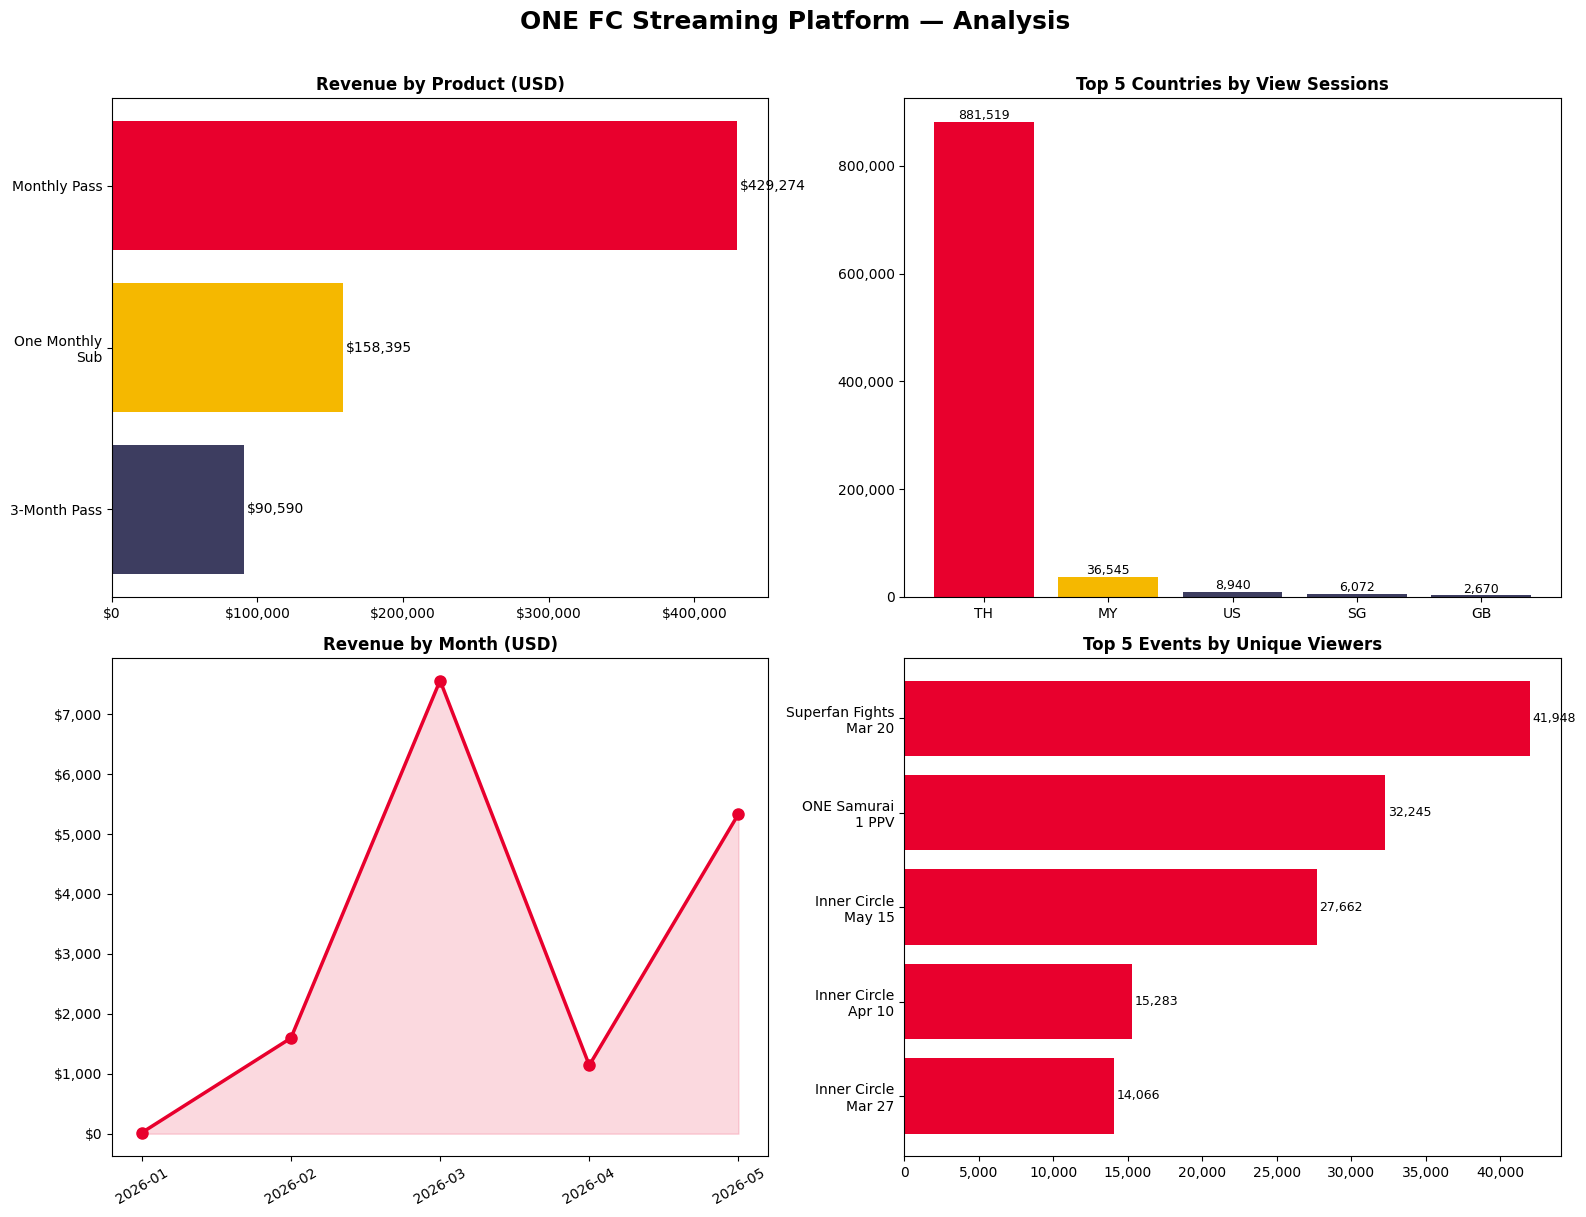

In [31]:
#create graphs!
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ONE FC Streaming Platform — Analysis', 
             fontsize=18, fontweight='bold', y=1.01)

#Revenue by Product
ax1 = axes[0, 0]
prod = (paid.groupby('internal_name')['total_charges_usd']
        .sum().sort_values())
colors = ['#3D3D60', '#F5B800', '#E8002D']
bars = ax1.barh(['3-Month Pass', 'One Monthly\nSub', 'Monthly Pass'],
                prod.values, color=colors)
ax1.set_title('Revenue by Product (USD)', fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, prod.values):
    ax1.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10)

#Top 5 Countries by View Sessions
ax2 = axes[0, 1]
top_countries = views['geo_country'].value_counts().head(5)
ax2.bar(top_countries.index, top_countries.values,
        color=['#E8002D','#F5B800','#3D3D60','#3D3D60','#3D3D60'])
ax2.set_title('Top 5 Countries by View Sessions', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
for i, val in enumerate(top_countries.values):
    ax2.text(i, val + 5000, f'{val:,}', ha='center', fontsize=9)

#Revenue by Month
ax3 = axes[1, 0]
monthly = (paid.groupby('order_month')['total_charges_usd']
           .sum().reset_index())
months  = [str(m) for m in monthly['order_month']]
ax3.plot(months, monthly['total_charges_usd'],
         color='#E8002D', marker='o', linewidth=2.5, markersize=8)
ax3.fill_between(months, monthly['total_charges_usd'],
                 alpha=0.15, color='#E8002D')
ax3.set_title('Revenue by Month (USD)', fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))
ax3.tick_params(axis='x', rotation=30)

#Top 5 Events by Unique Viewers
ax4 = axes[1, 1]
top_events = (real_events.groupby('event')['kiswe_user_id']
              .nunique().sort_values(ascending=False).head(5))
short_names = ['Superfan Fights\nMar 20', 'ONE Samurai\n1 PPV',
               'Inner Circle\nMay 15', 'Inner Circle\nApr 10',
               'Inner Circle\nMar 27']
ax4.barh(short_names[::-1], top_events.values[::-1],
         color='#E8002D')
ax4.set_title('Top 5 Events by Unique Viewers', fontweight='bold')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
for i, val in enumerate(top_events.values[::-1]):
    ax4.text(val + 200, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
#save graphs auto
plt.savefig('onefc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ONE FC Streaming Platform — Analysis Summary

## Key Findings
- **Total Revenue:** $678,258 from 87,614 orders (Avg $7.74/order)
- **Top Market:** 84% of view sessions and 84% of revenue are from Thailand ⚠️ concentration risk
- **Best Product:** 3-Month Pass price is the highest per order ($14.51) but the purchase is lowest sales volume → Should promote?
- **Top Event:** Most watch event is Superfan Fights unique viewers 41,948) but ONE Samurai 1 PPV has the highest engagement (9.8 sessions/viewer)
- **1,089 users** Registered but never watch → re-engagement campaign?

## Data Quality Issues
- `last_login` missing 80% → can't do churn analysis
- `country` data is inconsistent (TH/THA/Thailand) → must normalize after getting raw data, but why? can we make it normalize from the beginning?
- 7,164 orders has no user_id → LTV tracking incomplete; likely guest checkouts or deleted accounts

## Assumptions
- `fulfilled` and `completed` = Payment completed successfully 
- `kiswe_user_id` in viewdata = `user_id` in userdata
- Use `total_charges_usd` as revenue (because `charges_in_usd` is in raw JSON)